<a href="https://colab.research.google.com/github/r02x/Datasets/blob/main/Gr6homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploring Global Electricity Access in Schools Through Data Visualization to Support SDG 4 and SDG 7

In [ ]:
## introduction

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Datasets

In [ ]:
school = pd.read_csv("school_electricity_access.csv")

In [ ]:
school.shape

(675, 4)

In [ ]:
school.head()

,Country_Name,ISO_Code,Year,Electricity_Access_Percent
0,Albania,ALB,2018,94.085213
1,Albania,ALB,2019,97.713760
2,Andorra,AND,2016,100.000000
3,Andorra,AND,2017,100.000000
4,Andorra,AND,2018,100.000000


In [ ]:
school = pd.read_csv("school_electricity_access.csv")

gdp = pd.read_csv("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv", skiprows=4)
urban = pd.read_csv("API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_249.csv", skiprows=4)
electricity = pd.read_csv("API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_158.csv", skiprows=4)
education = pd.read_csv("API_SE.XPD.TOTL.GB.ZS_DS2_en_csv_v2_9902.csv", skiprows=4)

# Filtering School Data for 2019

In [ ]:
school = school[school["Year"] == 2019]

school = school.rename(columns={
    "Country_Name": "Country",
    "Electricity_Access_Percent": "School_Electricity_Access"
})

school = school[["Country", "School_Electricity_Access"]]

school.head()

,Country,School_Electricity_Access
1,Albania,97.71376
5,Andorra,100.00000
15,Armenia,100.00000
37,Azerbaijan,100.00000
42,Bahrain,100.00000


# Preparing Other Datasets

In [ ]:
year = "2019"

gdp = gdp[["Country Name", year]].rename(columns={year:"GDP_per_capita"})
urban = urban[["Country Name", year]].rename(columns={year:"Urban_population"})
electricity = electricity[["Country Name", year]].rename(columns={year:"Electricity_access"})
education = education[["Country Name", year]].rename(columns={year:"Education_expenditure"})

# Merging the Datasets

In [ ]:
df = school.merge(gdp, left_on="Country", right_on="Country Name")
df = df.merge(urban, on="Country Name")
df = df.merge(electricity, on="Country Name")
df = df.merge(education, on="Country Name")

# Handling Missing Values

In [ ]:
df = df.drop(columns=["Country Name"])
df = df.dropna()

# First Look at the Data

In [ ]:

df.head()

,Country,School_Electricity_Access,GDP_per_capita,Urban_population,Electricity_access,Education_expenditure
0,Albania,97.71376,6069.439031,56.763907,100.0,13.433400
1,Andorra,100.00000,41257.816459,88.539179,100.0,10.895240
2,Armenia,100.00000,4597.228874,65.004703,100.0,8.575244
3,Azerbaijan,100.00000,4805.753718,58.130819,100.0,9.767570
4,Bahrain,100.00000,27259.743860,100.000000,100.0,8.557403


In [ ]:
df.describe()

,School_Electricity_Access,GDP_per_capita,Urban_population,Electricity_access,Education_expenditure
count,57.000000,57.000000,57.000000,57.000000,57.000000
mean,77.047283,17171.710387,60.302990,83.650877,15.059245
std,33.424009,30970.926633,25.419652,28.622089,5.851911
min,2.896940,234.310616,16.813146,8.400000,4.834024
25%,45.835941,1767.072711,40.772289,70.400000,11.130557
50%,100.000000,5998.001743,58.130819,99.900000,14.178698
75%,100.000000,12884.685995,79.578002,100.000000,17.733021
max,100.000000,193746.785647,100.000000,100.000000,35.009998


In [ ]:
df.corr(numeric_only=True)

,School_Electricity_Access,GDP_per_capita,Urban_population,Electricity_access,Education_expenditure
School_Electricity_Access,1.000000,0.355287,0.532440,0.91299,-0.250374
GDP_per_capita,0.355287,1.000000,0.561719,0.30392,-0.270501
Urban_population,0.532440,0.561719,1.000000,0.57478,-0.250493
Electricity_access,0.912990,0.303920,0.574780,1.00000,-0.283810
Education_expenditure,-0.250374,-0.270501,-0.250493,-0.28381,1.000000


#Key Visualizations

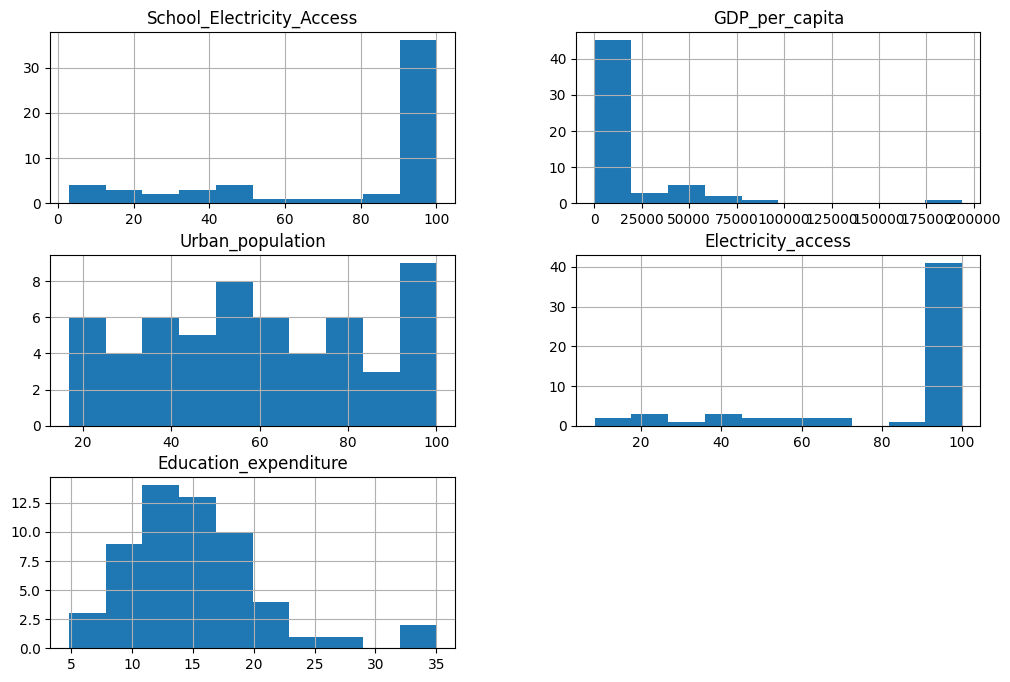

In [ ]:
df.hist(figsize=(12,8))
plt.show()

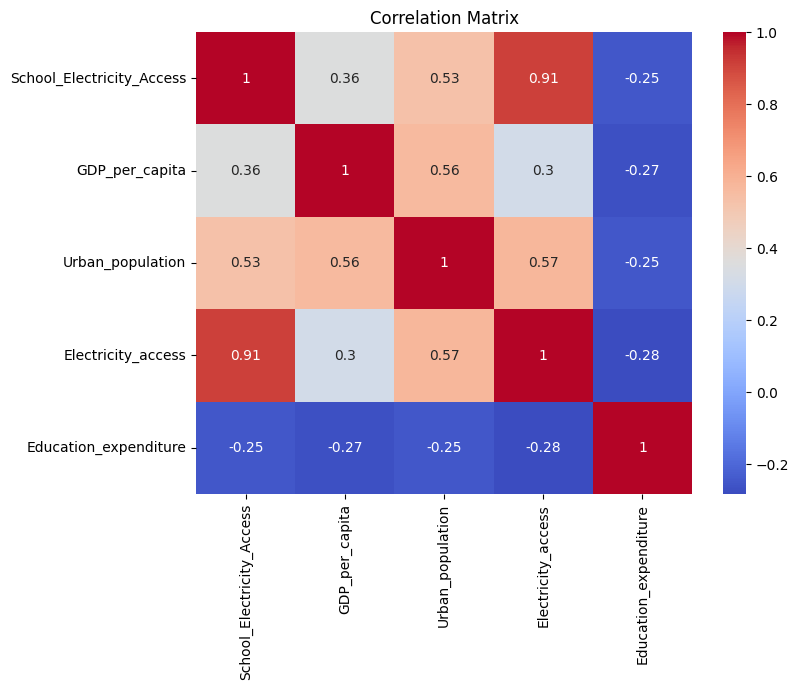

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

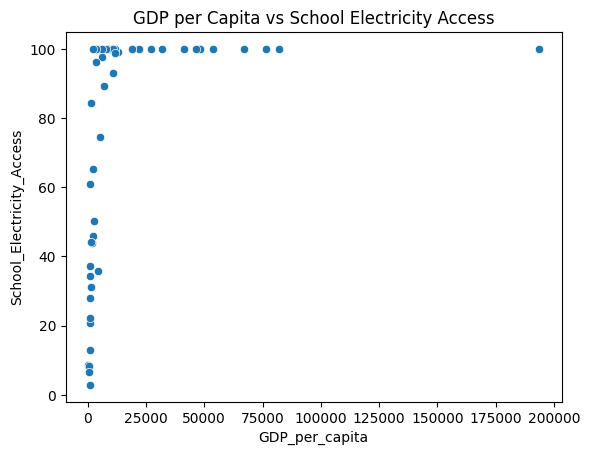

In [ ]:
sns.scatterplot(x="GDP_per_capita", y="School_Electricity_Access", data=df)
plt.title("GDP per Capita vs School Electricity Access")
plt.show()

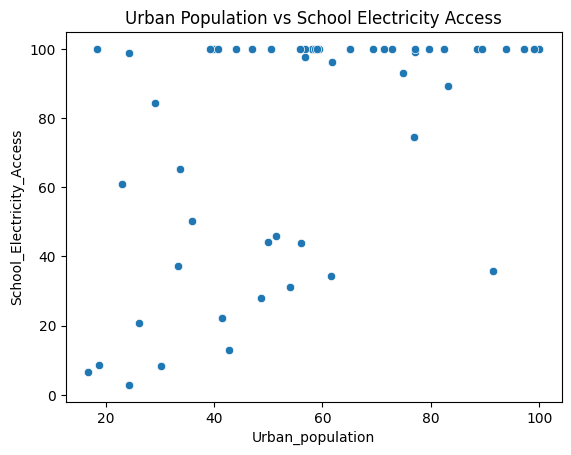

In [ ]:
sns.scatterplot(x="Urban_population", y="School_Electricity_Access", data=df)
plt.title("Urban Population vs School Electricity Access")
plt.show()

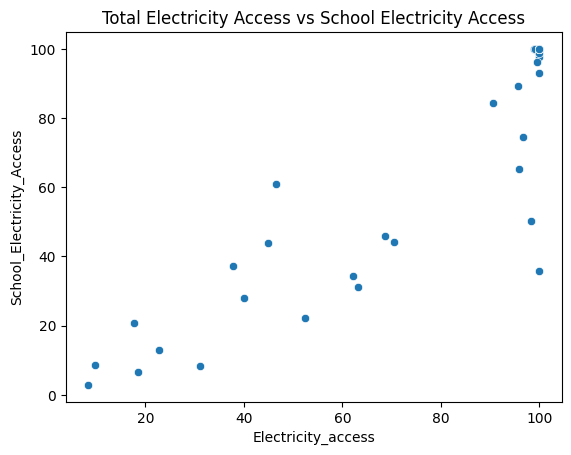

In [ ]:
sns.scatterplot(x="Electricity_access", y="School_Electricity_Access", data=df)
plt.title("Total Electricity Access vs School Electricity Access")
plt.show()

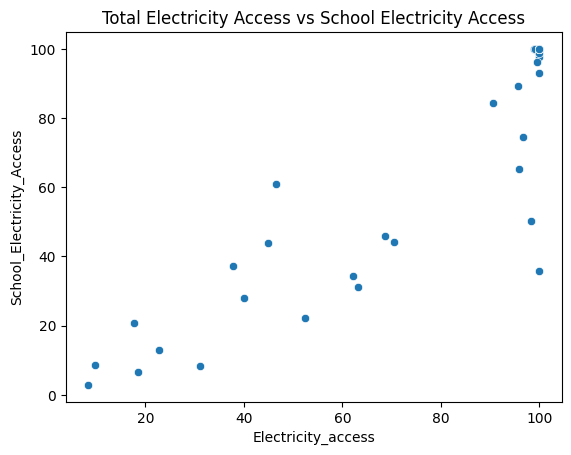

In [ ]:
sns.scatterplot(x="Electricity_access", y="School_Electricity_Access", data=df)
plt.title("Total Electricity Access vs School Electricity Access")
plt.show()

In [ ]:
df.to_csv("merged_dataset.csv", index=False)